In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [27]:
X, y = make_classification(
    n_samples=3000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=2.2,
    flip_y=0.02,
    random_state=42
)

data = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
data["Target"] = y

In [28]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nShape :", data.shape)

print("\nFirst Five Rows\n")
print(data.head())

print("\nDataset Information\n")
print(data.info())

print("\nStatistical Summary\n")
print(data.describe())

print("\nTarget Distribution\n")
print(data["Target"].value_counts())

DATASET INFORMATION

Shape : (3000, 3)

First Five Rows

   Feature_1  Feature_2  Target
0   2.760364   2.488921       1
1   2.447435   1.801672       1
2   0.878690  -2.842522       0
3   2.298299   2.823611       1
4   3.061258  -2.423691       0

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  3000 non-null   float64
 1   Feature_2  3000 non-null   float64
 2   Target     3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB
None

Statistical Summary

         Feature_1    Feature_2       Target
count  3000.000000  3000.000000  3000.000000
mean      2.180835     0.030822     0.501333
std       0.589027     2.329839     0.500082
min      -0.007834    -4.900996     0.000000
25%       1.797911    -2.161926     0.000000
50%       2.193198     0.567701     1.000000
75%       2.553266     2.23991

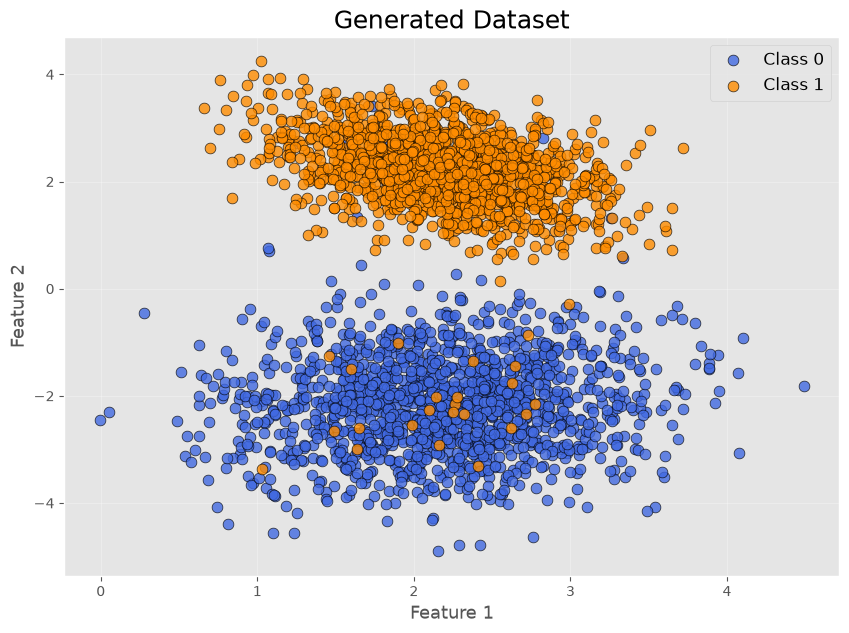

In [29]:
plt.figure(figsize=(10,7))

plt.scatter(
    data[data.Target==0]["Feature_1"],
    data[data.Target==0]["Feature_2"],
    color="royalblue",
    edgecolor="black",
    s=60,
    alpha=0.8,
    label="Class 0"
)

plt.scatter(
    data[data.Target==1]["Feature_1"],
    data[data.Target==1]["Feature_2"],
    color="darkorange",
    edgecolor="black",
    s=60,
    alpha=0.8,
    label="Class 1"
)

plt.title("Generated Dataset", fontsize=18)
plt.xlabel("Feature 1", fontsize=13)
plt.ylabel("Feature 2", fontsize=13)
plt.grid(True, alpha=.3)
plt.legend(fontsize=12)
plt.show()

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


Training Samples : 2400
Testing Samples  : 600


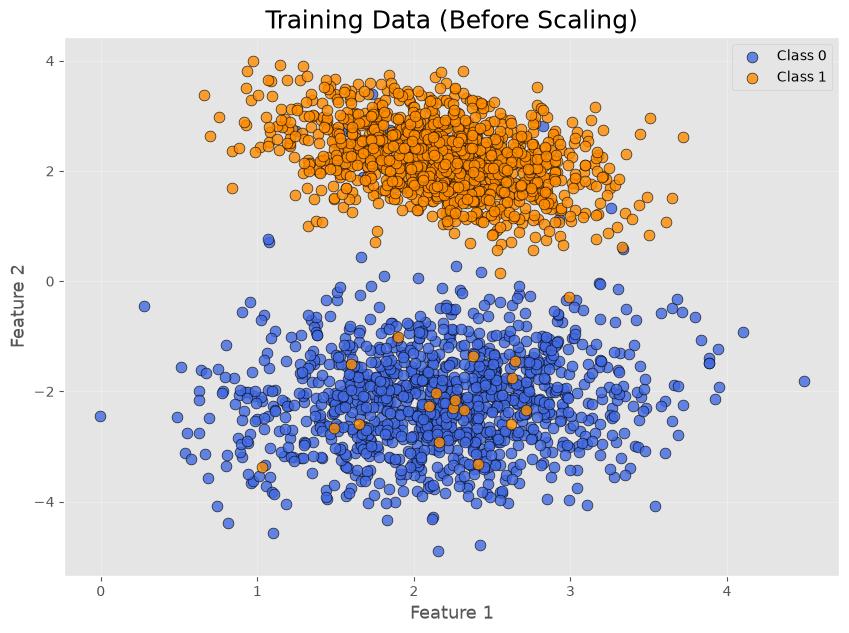

In [31]:
plt.figure(figsize=(10,7))

plt.scatter(
    X_train[y_train==0][:,0],
    X_train[y_train==0][:,1],
    color="royalblue",
    edgecolor="black",
    s=60,
    alpha=.8,
    label="Class 0"
)

plt.scatter(
    X_train[y_train==1][:,0],
    X_train[y_train==1][:,1],
    color="darkorange",
    edgecolor="black",
    s=60,
    alpha=.8,
    label="Class 1"
)

plt.title("Training Data (Before Scaling)", fontsize=18)
plt.xlabel("Feature 1", fontsize=13)
plt.ylabel("Feature 2", fontsize=13)
plt.grid(True, alpha=.3)
plt.legend()
plt.show()

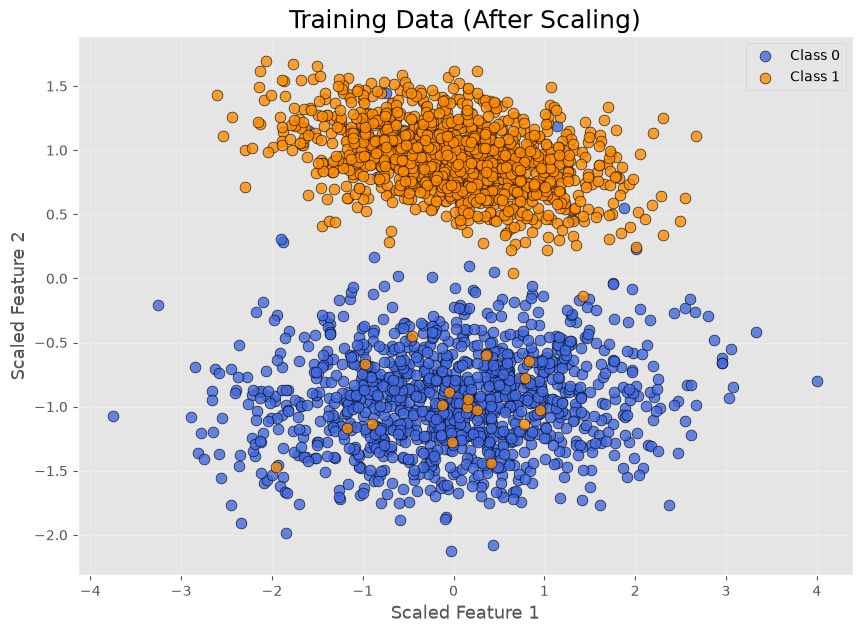

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


plt.figure(figsize=(10,7))

plt.scatter(
    X_train_scaled[y_train==0][:,0],
    X_train_scaled[y_train==0][:,1],
    color="royalblue",
    edgecolor="black",
    s=60,
    alpha=.8,
    label="Class 0"
)

plt.scatter(
    X_train_scaled[y_train==1][:,0],
    X_train_scaled[y_train==1][:,1],
    color="darkorange",
    edgecolor="black",
    s=60,
    alpha=.8,
    label="Class 1"
)

plt.title("Training Data (After Scaling)", fontsize=18)
plt.xlabel("Scaled Feature 1", fontsize=13)
plt.ylabel("Scaled Feature 2", fontsize=13)
plt.grid(True, alpha=.3)
plt.legend()
plt.show()

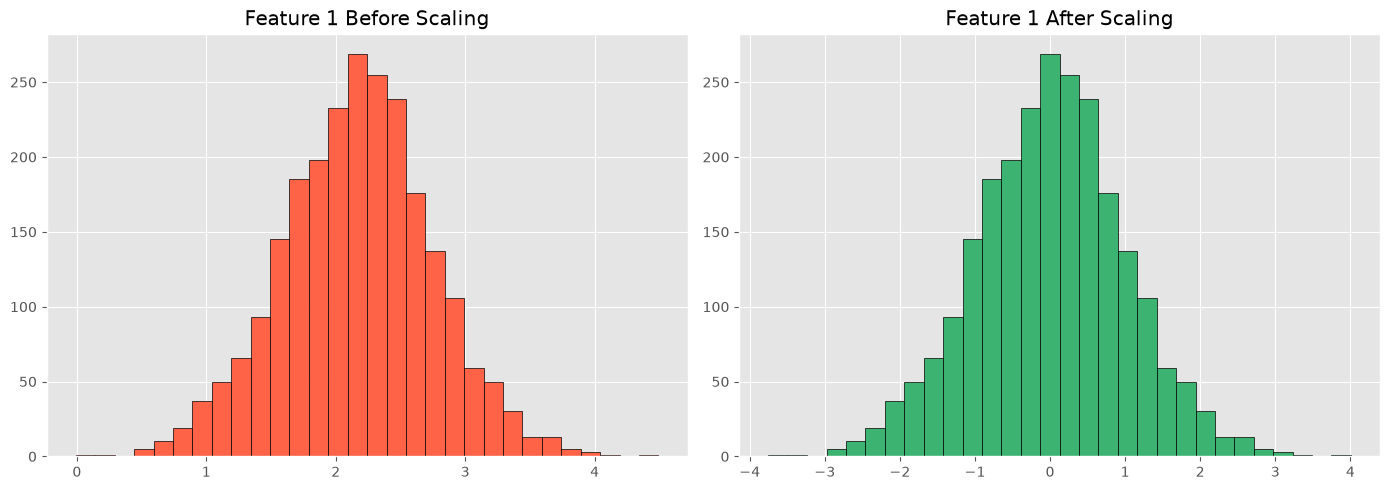

In [33]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].hist(
    X_train[:,0],
    bins=30,
    color="tomato",
    edgecolor="black"
)
ax[0].set_title("Feature 1 Before Scaling")

ax[1].hist(
    X_train_scaled[:,0],
    bins=30,
    color="mediumseagreen",
    edgecolor="black"
)
ax[1].set_title("Feature 1 After Scaling")

plt.tight_layout()
plt.show()

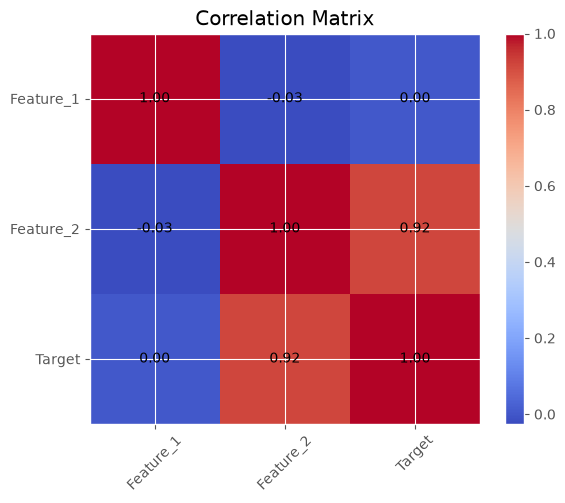


Data Preprocessing Completed Successfully!


In [34]:
plt.figure(figsize=(6,5))

corr = data.corr()

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nData Preprocessing Completed Successfully!")

In [35]:
from sklearn.svm import SVC
import time

start = time.time()

svm = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

end = time.time()

training_time = end - start

print("="*60)
print("LINEAR SVM MODEL")
print("="*60)

print(f"Kernel Used      : {svm.kernel}")
print(f"C Value          : {svm.C}")
print(f"Training Time    : {training_time:.5f} Seconds")

LINEAR SVM MODEL
Kernel Used      : linear
C Value          : 1.0
Training Time    : 0.04504 Seconds


In [37]:
print("="*60)
print("MODEL INFORMATION")
print("="*60)

print("\nNumber of Support Vectors for each Class")
print(svm.n_support_)

print("\nTotal Support Vectors")
print(sum(svm.n_support_))

print("\nShape of Support Vector Matrix")
print(svm.support_vectors_.shape)

print("\nIntercept (Bias)")
print(svm.intercept_)

print("\nCoefficients")
print(svm.coef_)

MODEL INFORMATION

Number of Support Vectors for each Class
[80 80]

Total Support Vectors
160

Shape of Support Vector Matrix
(160, 2)

Intercept (Bias)
[-0.25237399]

Coefficients
[[0.07458304 2.39200426]]


In [38]:
start = time.time()

train_prediction = svm.predict(X_train_scaled)

test_prediction = svm.predict(X_test_scaled)

end = time.time()

prediction_time = end - start

print("="*60)
print("PREDICTION COMPLETED")
print("="*60)

print(f"Prediction Time : {prediction_time:.5f} Seconds")

PREDICTION COMPLETED
Prediction Time : 0.01275 Seconds


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, test_prediction)

precision = precision_score(y_test, test_prediction)

recall = recall_score(y_test, test_prediction)

f1 = f1_score(y_test, test_prediction)

performance = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

performance

,Metric,Score
0,Accuracy,0.985000
1,Precision,0.989933
2,Recall,0.980066
3,F1 Score,0.984975


In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    test_prediction
))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       299
           1       0.99      0.98      0.98       301

    accuracy                           0.98       600
   macro avg       0.99      0.99      0.98       600
weighted avg       0.99      0.98      0.98       600



<Figure size 700x600 with 0 Axes>

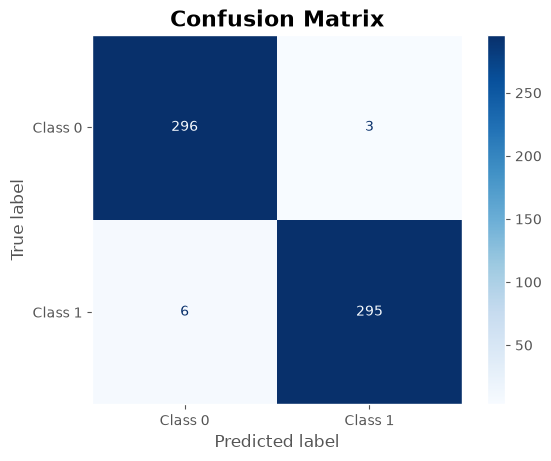

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_prediction
)

plt.figure(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0","Class 1"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.grid(False)

plt.show()

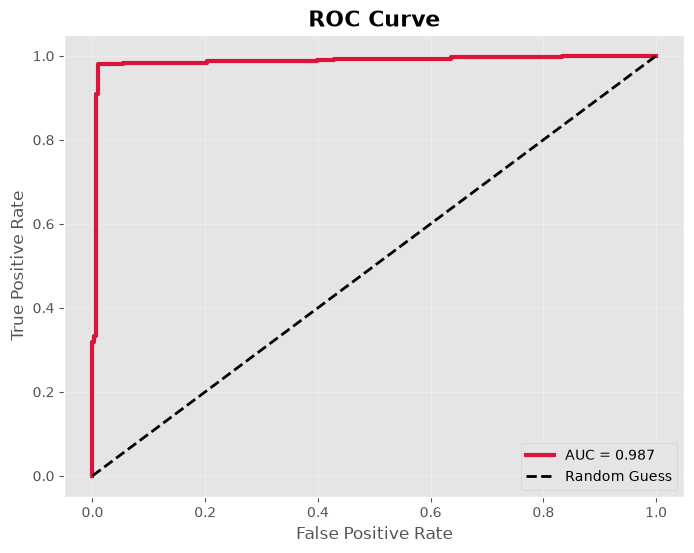

In [42]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

scores = svm.decision_function(
    X_test_scaled
)

fpr, tpr, threshold = roc_curve(
    y_test,
    scores
)

auc = roc_auc_score(
    y_test,
    scores
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    color="crimson",
    linewidth=3,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    linewidth=2,
    label="Random Guess"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=.3)

plt.legend()

plt.show()

In [43]:
dashboard = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC",

        "Support Vectors",

        "Training Time",

        "Prediction Time"

    ],

    "Value":[

        round(accuracy,4),

        round(precision,4),

        round(recall,4),

        round(f1,4),

        round(auc,4),

        sum(svm.n_support_),

        round(training_time,5),

        round(prediction_time,5)

    ]

})

dashboard

,Metric,Value
0,Accuracy,0.98500
1,Precision,0.98990
2,Recall,0.98010
3,F1 Score,0.98500
4,ROC AUC,0.98690
5,Support Vectors,160.00000
6,Training Time,0.04504
7,Prediction Time,0.01275


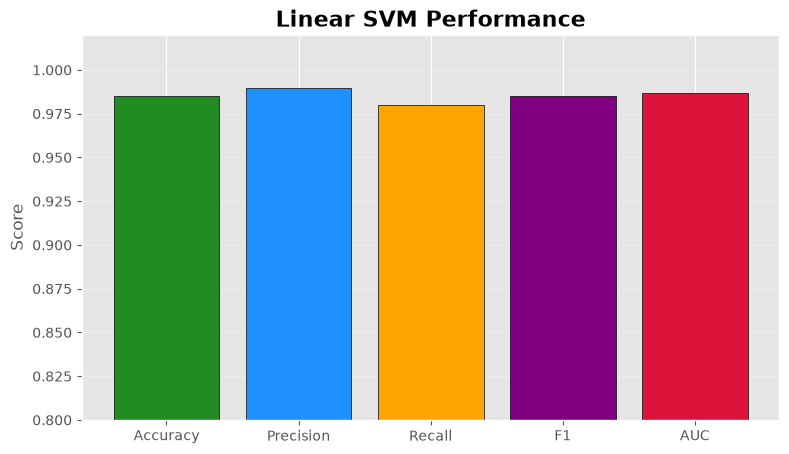

In [44]:
plt.figure(figsize=(9,5))

colors = [

    "forestgreen",

    "dodgerblue",

    "orange",

    "purple",

    "crimson"

]

plt.bar(

    ["Accuracy","Precision","Recall","F1","AUC"],

    [accuracy,precision,recall,f1,auc],

    color=colors,

    edgecolor="black"

)

plt.ylim(.8,1.02)

plt.ylabel("Score")

plt.title(

    "Linear SVM Performance",

    fontsize=16,

    fontweight="bold"

)

plt.grid(axis="y",alpha=.3)

plt.show()

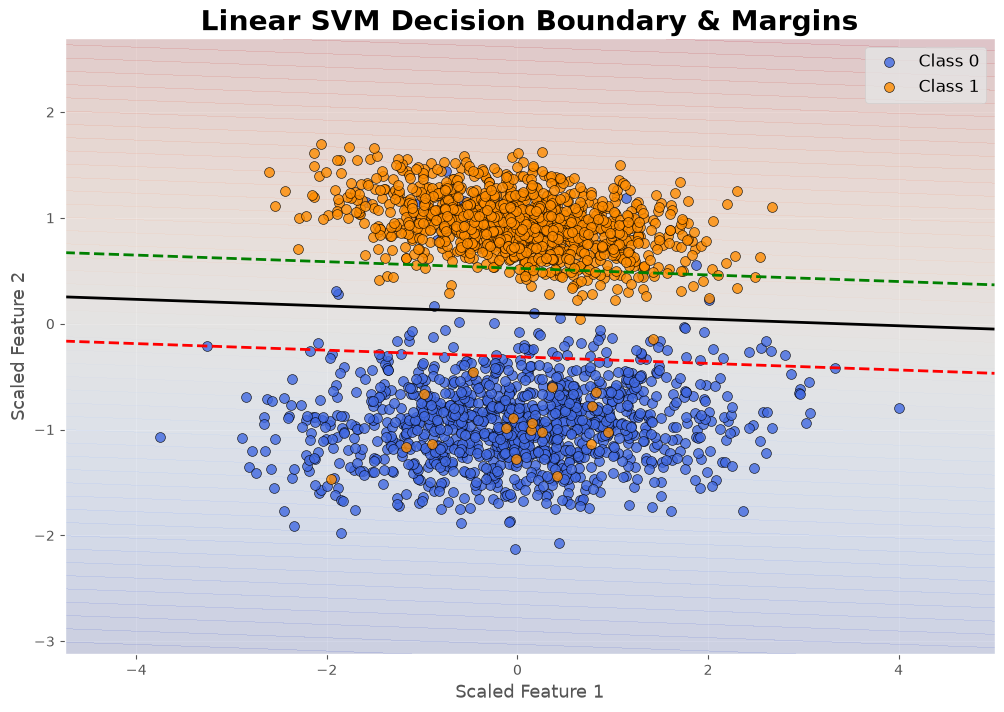

In [55]:
import numpy as np
import matplotlib.pyplot as plt

x_min = X_train_scaled[:,0].min() - 1
x_max = X_train_scaled[:,0].max() + 1

y_min = X_train_scaled[:,1].min() - 1
y_max = X_train_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = svm.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(12,8))

plt.contourf(
    xx,
    yy,
    Z,
    levels=50,
    cmap="coolwarm",
    alpha=0.15
)

plt.contour(
    xx,
    yy,
    Z,
    levels=[-1,0,1],
    colors=["red","black","green"],
    linestyles=["--","-","--"],
    linewidths=2
)

plt.scatter(
    X_train_scaled[y_train==0][:,0],
    X_train_scaled[y_train==0][:,1],
    c="royalblue",
    edgecolors="black",
    s=50,
    alpha=0.80,
    label="Class 0"
)

plt.scatter(
    X_train_scaled[y_train==1][:,0],
    X_train_scaled[y_train==1][:,1],
    c="darkorange",
    edgecolors="black",
    s=50,
    alpha=0.80,
    label="Class 1"
)

plt.title(
    "Linear SVM Decision Boundary & Margins",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Scaled Feature 1", fontsize=13)
plt.ylabel("Scaled Feature 2", fontsize=13)

plt.legend(fontsize=12)

plt.grid(alpha=0.25)

plt.show()

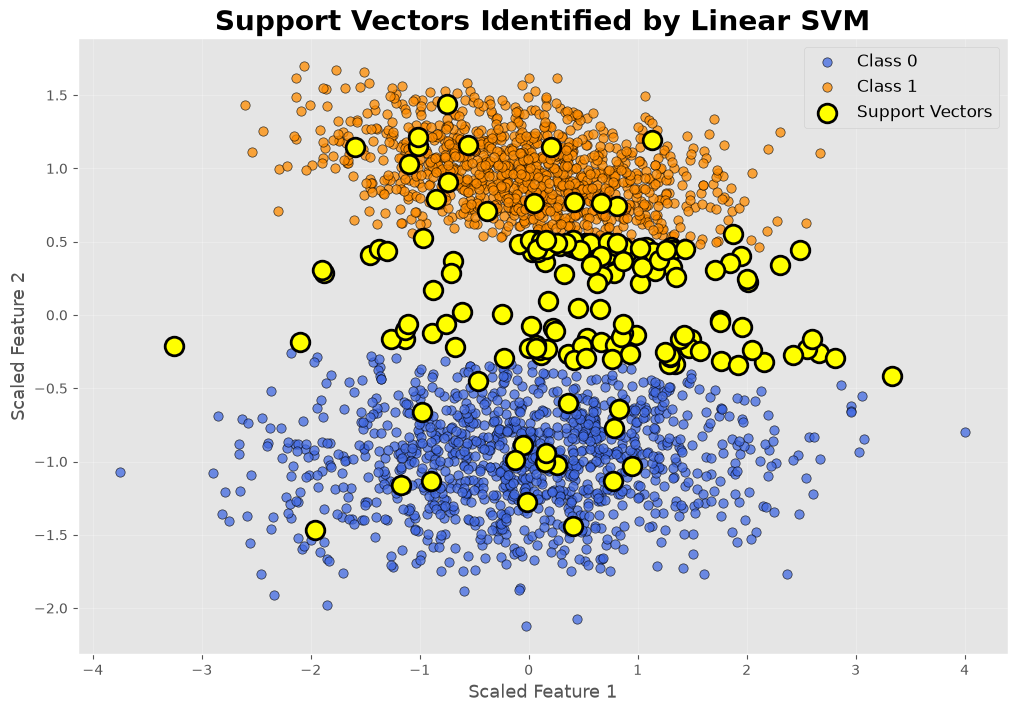

SUPPORT VECTOR INFORMATION
Support Vectors Per Class : [80 80]
Total Support Vectors     : 160


In [56]:
plt.figure(figsize=(12,8))

plt.scatter(
    X_train_scaled[y_train==0][:,0],
    X_train_scaled[y_train==0][:,1],
    c="royalblue",
    edgecolors="black",
    s=45,
    alpha=0.75,
    label="Class 0"
)

plt.scatter(
    X_train_scaled[y_train==1][:,0],
    X_train_scaled[y_train==1][:,1],
    c="darkorange",
    edgecolors="black",
    s=45,
    alpha=0.75,
    label="Class 1"
)

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=180,
    facecolors="yellow",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.title(
    "Support Vectors Identified by Linear SVM",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Scaled Feature 1", fontsize=13)
plt.ylabel("Scaled Feature 2", fontsize=13)

plt.legend(fontsize=12)

plt.grid(alpha=0.25)

plt.show()

print("="*60)
print("SUPPORT VECTOR INFORMATION")
print("="*60)

print("Support Vectors Per Class :", svm.n_support_)
print("Total Support Vectors     :", sum(svm.n_support_))

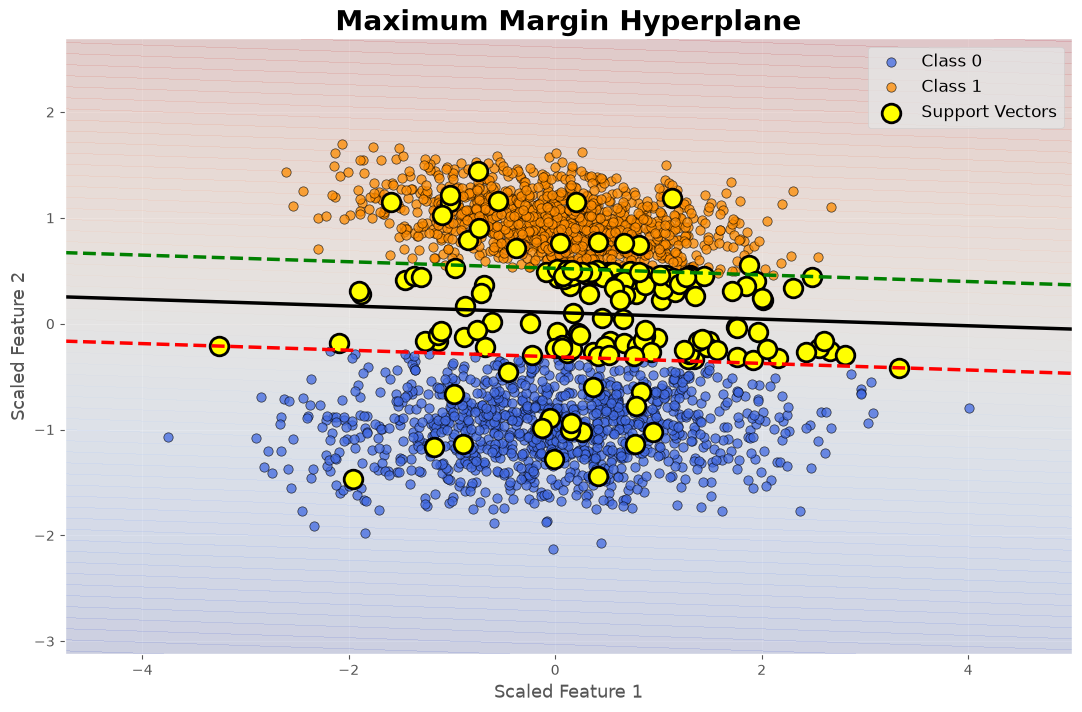

In [57]:
x_min = X_train_scaled[:,0].min() - 1
x_max = X_train_scaled[:,0].max() + 1

y_min = X_train_scaled[:,1].min() - 1
y_max = X_train_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = svm.decision_function(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(13,8))

plt.contourf(
    xx,
    yy,
    Z,
    levels=60,
    cmap="coolwarm",
    alpha=0.15
)

plt.contour(
    xx,
    yy,
    Z,
    levels=[-1,0,1],
    colors=["red","black","green"],
    linestyles=["--","-","--"],
    linewidths=2.5
)

plt.scatter(
    X_train_scaled[y_train==0][:,0],
    X_train_scaled[y_train==0][:,1],
    c="royalblue",
    edgecolors="black",
    s=45,
    alpha=0.75,
    label="Class 0"
)

plt.scatter(
    X_train_scaled[y_train==1][:,0],
    X_train_scaled[y_train==1][:,1],
    c="darkorange",
    edgecolors="black",
    s=45,
    alpha=0.75,
    label="Class 1"
)

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=180,
    facecolors="yellow",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.title(
    "Maximum Margin Hyperplane",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Scaled Feature 1", fontsize=13)
plt.ylabel("Scaled Feature 2", fontsize=13)

plt.legend(fontsize=12)

plt.grid(alpha=0.25)

plt.show()

In [48]:
margin_width = 2 / np.linalg.norm(w)

print("="*60)
print("MARGIN INFORMATION")
print("="*60)

print(f"Weight Vector (w) : {w}")
print(f"Bias (b)          : {b:.4f}")

print(f"\nMargin Width      : {margin_width:.4f}")

MARGIN INFORMATION
Weight Vector (w) : [0.07458304 2.39200426]
Bias (b)          : -0.2524

Margin Width      : 0.8357


In [49]:
summary = pd.DataFrame({

    "Metric":[
        "Kernel",
        "Training Samples",
        "Testing Samples",
        "Support Vectors",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        "Linear",
        len(X_train_scaled),
        len(X_test_scaled),
        sum(svm.n_support_),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(auc,4)
    ]
})

summary

,Metric,Value
0,Kernel,Linear
1,Training Samples,2400
2,Testing Samples,600
3,Support Vectors,160
4,Accuracy,0.985
5,Precision,0.9899
6,Recall,0.9801
7,F1 Score,0.985
8,ROC AUC,0.9869


In [50]:
print("="*70)
print("LINEAR SVM PROJECT SUMMARY")
print("="*70)

print(f"""
Dataset Size      : {len(X)}

Kernel Used       : Linear

Accuracy          : {accuracy:.4f}

Precision         : {precision:.4f}

Recall            : {recall:.4f}

F1 Score          : {f1:.4f}

ROC AUC           : {auc:.4f}

Support Vectors   : {sum(svm.n_support_)}

Margin Width      : {margin_width:.4f}

Training Time     : {training_time:.5f} Seconds

Prediction Time   : {prediction_time:.5f} Seconds
""")

print("="*70)
print("Linear SVM Successfully Completed")
print("="*70)

LINEAR SVM PROJECT SUMMARY

Dataset Size      : 3000

Kernel Used       : Linear

Accuracy          : 0.9850

Precision         : 0.9899

Recall            : 0.9801

F1 Score          : 0.9850

ROC AUC           : 0.9869

Support Vectors   : 160

Margin Width      : 0.8357

Training Time     : 0.04504 Seconds

Prediction Time   : 0.01275 Seconds

Linear SVM Successfully Completed
